# Highpass fixAR-IRLS vs iRRR_AR: Y scaled vs unscaled

This notebook summarizes the continuous Cz-EEG → fNIRS (HbO) HRF models fit on **highpassed fNIRS (`Hp`)**:

| Model | Script | Scaled output | Unscaled output |
|---|---|---|---|
| **fixAR-IRLS** | `run_model_cont_EEG_fNIRS_fixAR-IRLS.py` | `*_cont_EEG_cz_3-stage_fixAR-IRLS_Hp_*` | `*_cont_EEG_cz_3-stage_fixAR-IRLS_noScale_Hp_*` |
| **iRRR_AR** | `run_model_cont_EEG_fNIRS_iRRR_AR.py` | `*_cont_EEG_cz_3-stage_iRRR_AR_Hp_*` | `*_cont_EEG_cz_3-stage_iRRR_AR_noScale_Hp_*` |

Contents:
1. Preprocessing steps (shared inputs, then each model)
2. Fit summary: `Y_scale` and iRRR rank per subject
3. R² and RMSE: bar plots and brain-surface maps
4. HRFs at the 5 parcels nearest to Cz
5. iRRR_AR shared HRF components and their per-parcel weights on the brain surface

All fits are in-sample, and all metrics are computed in the **spectrally whitened** space that both models are fit in.

## 1. Preprocessing

### 1a. Shared inputs (identical for both models and both scaling options)

Both models load the same `Y_all` (fNIRS) and `dm_all` (EEG design matrix). The AR-IRLS run `run_model_cont_EEG_fNIRS.py` (`eeg_reg_type = 'cont_EEG_cz_3-stage_bspline-test'`, `is_hp_fNIRS = True`) saved them. Only the fitting step differs between the models.

**Subjects.** A subject is included if they have gradCPT fNIRS and at least 500 clean EEG epochs (−0.2 to 1.0 s, rejected above 100 µV). Subjects in `excluded_subj` (low fNIRS quality) are dropped, as are subjects whose Cz was removed in any run. Six subjects remain.

**fNIRS → `Y_all` (time × parcel, HbO)**
1. Load the preprocessed parcel time series (`parcel_ts`) from image reconstruction: probe Adot v26, vertex space, from `derivatives/cedalion/pipeline_reorder/processed_data`.
2. Remove the `scalp` parcel. Keep parcels with forward-model sensitivity `log10(Σ_channel A) > −2`, excluding the medial wall: 429 of 601 atlas parcels, of which 417 appear in `Y_all`. Keep **HbO** only.
3. **Highpass**: 4th-order Butterworth at **0.02 Hz**, zero-phase (`sosfiltfilt`), per run. This is the `Hp` in the file names.
4. Truncate each run to [first event onset, last event onset + 15 s].
5. **Stage 1 (drift)**: per run, OLS-regress out 3rd-order Legendre drift.
6. **Stage 2 (GSR)**: per run, OLS-regress out the global mean signal, computed from the drift residuals.
7. Concatenate the 3 runs. The result is `Y_all` = Y_partial = Y_raw − Ŷ_drift − Ŷ_GSR.

**EEG → `dm_all` (time × 15 regressors)**
1. EEG preprocessing (`utils.eeg_preproc_subj_level`): bandpass 0.1–45 Hz, re-reference to TP9h/TP10h, ICA removal of eye artifacts.
2. Synchronize EEG to the fNIRS clock using the event onsets. Crop EEG to start 15 s before the fNIRS window, so every fNIRS sample has 15 s of EEG history.
3. Build an FIR design matrix from the **raw Cz signal** (no z-score) with delays 0–15 s at the EEG sampling rate (7500 delay taps).
4. Project the delay axis onto **15 cubic B-spline basis functions** (`bspline0…14`, intercept included). This constrains the HRF to be smooth and low-dimensional.
5. Resample the regressors from the EEG rate to the fNIRS rate (`mne.filter.resample`) and match the fNIRS sample count.
6. Recover the HRF as `betas_eeg = betas_bspline · basis`, giving 7500 delay taps over 0–15 s.

### 1b. Spectral whitening (both models)
1. OLS fit `Y_all ~ 1 + X`, then take the residuals.
2. Estimate each parcel's residual autocorrelation (per-run zero-padded autocovariance, Tukey taper with M = √N lags). Average the spectrum across parcels to get **one shared kernel**, 1/√PSD with the DC bin set to 0.
3. Apply the kernel per run to both Y and X: `Y_white = W·Y`, `X_white = W·X`. The whitened series are zero-mean.

### 1c. fixAR-IRLS
- The noise model is fixed to the spectral kernel above. There is no iterative AR re-estimation, unlike cedalion's AR-IRLS.
- Fit each parcel independently with a robust regression of `Y_white` on `X_white` (statsmodels `RLM`, Tukey biweight, c = 4.685). There is no intercept, because the whitened data are zero-mean.
- Saved statistics: an F-test (all B-spline betas = 0) and a t-test (sum of B-spline betas = 0).

### 1d. iRRR_AR
- Fit all parcels jointly: `Y_white (T×P) ~ X_white (T×15) + μ`. A nuclear-norm penalty on the 15×P coefficient matrix makes all parcels' HRFs share a low-rank set of shapes.
- λ₁ = 1. The penalty weight is `w = σ_max(X_c)(√P + √rank X_c)/T`. Solved by ADMM with varying ρ, tolerance 0.01.

### 1e. Y scaling (`is_scale_Y`)
- **Scaled** (default): divide `Y_white` by its global standard deviation (one scalar per subject, about 1–2.5×10⁻⁸ M) before fitting, then multiply the betas (and iRRR μ) back. With scaling, λ₁ = 1 means the same thing in every subject, and the RLM tolerances act on O(1) numbers.
- **Unscaled**: fit directly in molar units (about 10⁻⁸).

In [1]:
%matplotlib inline
import os, sys, pickle, gzip, glob, re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pyvista as pv
pv.OFF_SCREEN = True

sys.path.insert(0, os.getcwd())
from params_setting import *
import model
import cedalion.dot
from cedalion.vis.anatomy.image_recon import image_recon, image_recon_multi_view
from cedalion.vis.blocks import plot_labeled_points

eeg_reg_type = 'cont_EEG_cz_3-stage'
ar_irls_reg_type = 'cont_EEG_cz_3-stage_bspline-test'   # run that saved Y_all / dm_all
hp_flag = 'Hp'
select_chromo = 'HbO'
len_delay = 15     # s
n_cz_parcels = 5

eeg_der_dir = os.path.join(project_path, 'derivatives', 'eeg')
fig_dir = os.path.join(eeg_der_dir, 'HRF_surf', 'group', f'{eeg_reg_type}_model_cmp', f'summary_{hp_flag}')
os.makedirs(fig_dir, exist_ok=True)

# variant label -> (model, reg_type)
variants = {
    'fixAR-IRLS (scaled)':   ('fixAR-IRLS', f'{eeg_reg_type}_fixAR-IRLS{get_scale_tag(True)}'),
    'fixAR-IRLS (unscaled)': ('fixAR-IRLS', f'{eeg_reg_type}_fixAR-IRLS{get_scale_tag(False)}'),
    'iRRR_AR (scaled)':      ('iRRR_AR',    f'{eeg_reg_type}_iRRR_AR{get_scale_tag(True)}'),
    'iRRR_AR (unscaled)':    ('iRRR_AR',    f'{eeg_reg_type}_iRRR_AR{get_scale_tag(False)}'),
}
colors = {'fixAR-IRLS (scaled)': '#2a78d6', 'fixAR-IRLS (unscaled)': '#8fbdf0',
          'iRRR_AR (scaled)': '#d6336c', 'iRRR_AR (unscaled)': '#f2a7c3'}
labels = list(variants)

def prefix(subject, reg_type):
    return os.path.join(eeg_der_dir, subject, f'{subject}_{reg_type}_{hp_flag}')

# subjects with all four variants
subjects = sorted(
    s for s in {re.search(r'(sub-\d+)', f).group(1) for f in glob.glob(os.path.join(eeg_der_dir, 'sub-*', 'betas', f'*_{eeg_reg_type}_fixAR-IRLS_{hp_flag}_betas.pkl'))}
    if s not in excluded_subj
    and all(os.path.exists(get_betas_path(prefix(s, rt))) and os.path.exists(get_stats_path(prefix(s, rt))) for _, rt in variants.values())
)
print(f'{len(subjects)} subjects: {subjects}')

Using matplotlib as 2D backend.


6 subjects: ['sub-670', 'sub-695', 'sub-721', 'sub-723', 'sub-726', 'sub-730']


## 2. Load fits and score them

For each subject, `Y_all` and `dm_all` are whitened with the saved spectral kernel. The kernel is identical for all four variants, and the code asserts this. Each variant's prediction is then compared with `W·Y_partial`:
- fixAR-IRLS: `Ŷ = (W·X) B`
- iRRR_AR: `Ŷ = (W·X) C + μ`

RMSE is reported in µM.

In [2]:
def fit_metrics(Y, Y_hat):
    res = Y - Y_hat
    rmse = np.sqrt(np.nanmean(res**2, axis=0))
    r2 = 1 - np.nansum(res**2, axis=0) / np.nansum((Y - np.nanmean(Y, axis=0))**2, axis=0)
    return rmse, r2

rows, fit_rows = [], []
hrf = {lab: {} for lab in labels}        # label -> subject -> betas_eeg (parcel x delay) DataArray
irrr_stats = {lab: {} for lab in labels if variants[lab][0] == 'iRRR_AR'}
for subject in subjects:
    ar_prefix = os.path.join(eeg_der_dir, subject, f'{subject}_{ar_irls_reg_type}_{NOISE_MODEL}_{hp_flag}')
    with gzip.open(get_shared_Y_all_path(os.path.join(eeg_der_dir, subject), subject, hp_flag), 'rb') as f:
        Y_all = pickle.load(f)
    with gzip.open(get_dm_all_path(ar_prefix), 'rb') as f:
        dm_all = pickle.load(f)
    Y_da = Y_all.sel(chromo=select_chromo).pint.dequantify().transpose('time', 'parcel')
    X_da = dm_all.common.sel(chromo=select_chromo).transpose('time', 'regressor')
    parcels, regs = Y_da.parcel.values, X_da.regressor.values
    samples = Y_da.samples.values

    W_ref = None
    for lab, (mdl, rt) in variants.items():
        with open(get_betas_path(prefix(subject, rt)), 'rb') as f:
            betas_dict = pickle.load(f)
        with open(get_stats_path(prefix(subject, rt)), 'rb') as f:
            stats = pickle.load(f)
        if W_ref is None:
            W_ref = stats['whiten_kernel_fft']
            nm = model.NoiseModel(); nm.W_fft = W_ref; nm.w_pad = W_ref.shape[0]
            whiten = lambda a: np.vstack(nm.whiten(model.split_runs(a, samples)))
            Y_white, X_white = whiten(Y_da.values), whiten(X_da.values)
        assert np.allclose(stats['whiten_kernel_fft'], W_ref), f'{subject} {lab}: whitening kernels differ'

        B = betas_dict['betas'].sel(chromo=select_chromo, parcel=parcels, regressor=regs).transpose('regressor', 'parcel').values
        Y_hat = X_white @ B
        if mdl == 'iRRR_AR':
            mu = pd.Series(stats['intercept'].ravel(), index=betas_dict['betas'].parcel.values)[parcels].values
            Y_hat = Y_hat + mu
            irrr_stats[lab][subject] = stats
        rmse, r2 = fit_metrics(Y_white, Y_hat)
        rows.append(pd.DataFrame({'subject': subject, 'variant': lab, 'parcel': parcels, 'rmse': rmse * 1e6, 'r2': r2}))
        fit_rows.append({'subject': subject, 'variant': lab, 'Y_scale': stats['Y_scale'],
                         'rank': stats.get('rank', np.nan), 'max|B|': np.abs(B).max()})
        hrf[lab][subject] = betas_dict['betas_eeg'].sel(chromo=select_chromo)

metrics_df = pd.concat(rows, ignore_index=True)
fit_df = pd.DataFrame(fit_rows)
n_delay = hrf[labels[0]][subjects[0]].sizes['regressor']
delay_t = np.arange(n_delay) * (len_delay / n_delay)
print(f'{len(parcels)} parcels, {n_delay} delay taps')

417 parcels, 7500 delay taps


### Fit summary
`Y_scale` is the scalar the fit divided `Y_white` by (it is 1 for unscaled fits). `rank` is the rank of the iRRR coefficient matrix.

In [3]:
summary_tbl = fit_df.pivot(index='subject', columns='variant', values=['Y_scale', 'rank', 'max|B|'])
display(summary_tbl.loc[:, (slice(None), labels)].style.format('{:.3g}'))

# how much do scaled and unscaled fixAR-IRLS betas differ?
for subject in subjects:
    a = hrf['fixAR-IRLS (scaled)'][subject].values; b = hrf['fixAR-IRLS (unscaled)'][subject].values
    print(f"{subject}: fixAR-IRLS scaled vs unscaled HRF  r = {np.corrcoef(a.ravel(), b.ravel())[0, 1]:.4f}, "
          f"rel. diff = {np.linalg.norm(a - b) / np.linalg.norm(a):.3f}")

sub-670: fixAR-IRLS scaled vs unscaled HRF  r = 0.8318, rel. diff = 0.555
sub-695: fixAR-IRLS scaled vs unscaled HRF  r = 0.8227, rel. diff = 0.630
sub-721: fixAR-IRLS scaled vs unscaled HRF  r = 0.9957, rel. diff = 0.093
sub-723: fixAR-IRLS scaled vs unscaled HRF  r = 0.9844, rel. diff = 0.192


sub-726: fixAR-IRLS scaled vs unscaled HRF  r = 0.9801, rel. diff = 0.201
sub-730: fixAR-IRLS scaled vs unscaled HRF  r = 0.9969, rel. diff = 0.079


## 3. R² and RMSE

### 3a. Bar plots
Each subject's bar is the mean over parcels. The rightmost group is the mean ± SEM across subjects.

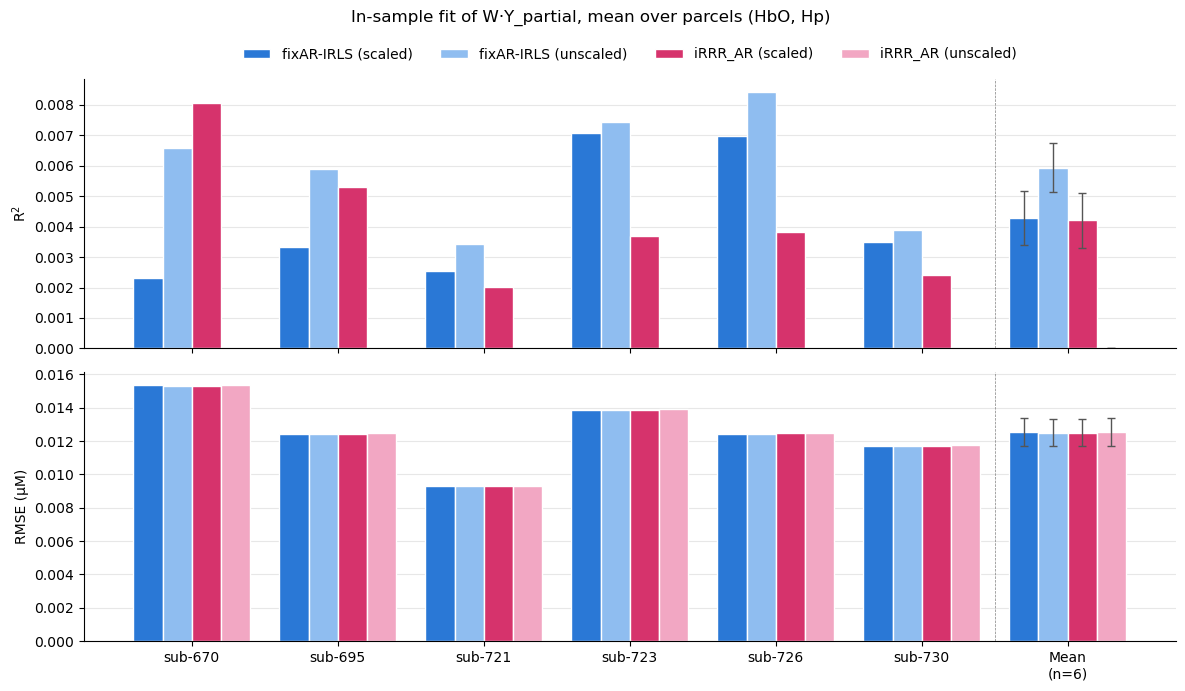

In [4]:
subj_df = metrics_df.groupby(['subject', 'variant'])[['rmse', 'r2']].mean().reset_index()
summ = subj_df.groupby('variant')[['rmse', 'r2']].agg(['mean', 'sem']).reindex(labels)
display(summ.style.format('{:.4g}'))

x_labels = subjects + [f'Mean\n(n={len(subjects)})']
x = np.arange(len(x_labels)); bw = 0.8 / len(labels)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, (metric, ylab) in zip(axes, [('r2', 'R$^2$'), ('rmse', 'RMSE (µM)')]):
    for i, lab in enumerate(labels):
        v = subj_df[subj_df.variant == lab].set_index('subject')[metric][subjects].values
        vals = np.append(v, summ.loc[lab, (metric, 'mean')])
        err = np.append(np.full(len(subjects), np.nan), summ.loc[lab, (metric, 'sem')])
        ax.bar(x + (i - (len(labels) - 1) / 2) * bw, vals, bw, yerr=err, color=colors[lab], label=lab,
               edgecolor='white', linewidth=1, error_kw={'elinewidth': 1, 'capsize': 3, 'ecolor': '#555'})
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(len(subjects) - 0.5, color='gray', lw=0.5, ls='--')
    ax.set_ylabel(ylab); ax.grid(True, axis='y', alpha=0.3); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncols=4, frameon=False)
axes[-1].set_xticks(x, x_labels)
fig.suptitle(f'In-sample fit of W·Y_partial, mean over parcels ({select_chromo}, {hp_flag})')
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'bar_r2_rmse.png'), dpi=150)
plt.show()

### 3b. Brain-surface maps (per-parcel mean across subjects)
- **R²** uses a linear scale from 0 to the maximum over all variants. Parcels with R² ≤ 0 are drawn black, and parcels that were not modeled are gray.
- **RMSE** uses absolute values in µM, on a color scale shared by all variants.

2026-10-09 10:11:27.665 (  13.514s) [    1492598DF400]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


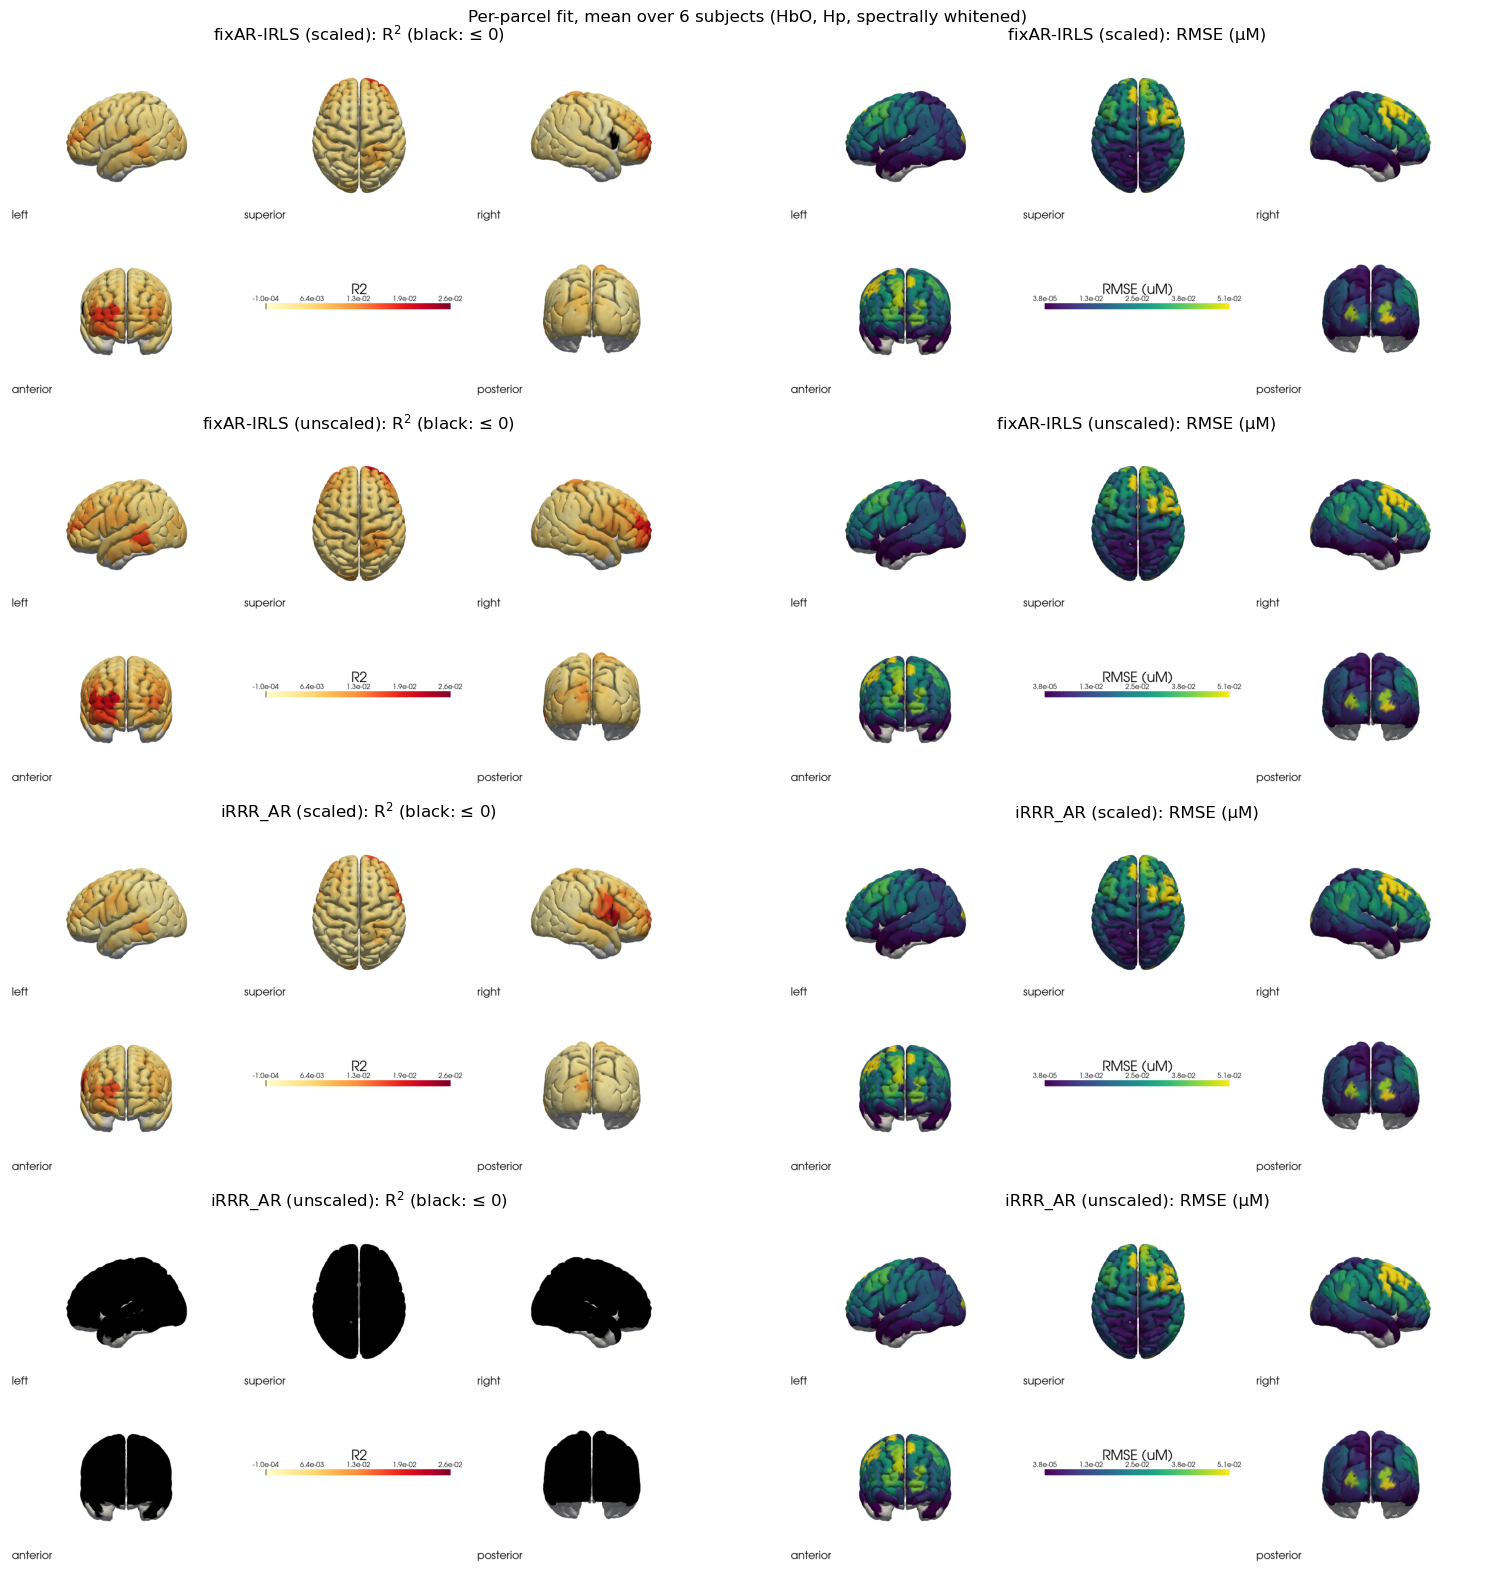

In [5]:
head = cedalion.dot.get_standard_headmodel('icbm152')
vertex_parcel = head.brain.vertices.parcel.values
n_vertex = head.brain.nvertices

def parcel_to_surf(val_by_parcel):
    v = np.array([val_by_parcel.get(p, np.nan) for p in vertex_parcel])
    return xr.DataArray(np.stack([v, np.zeros(n_vertex)], axis=-1), dims=['vertex', 'chromo'],
                        coords={'chromo': ['HbO', 'HbR'], 'is_brain': ('vertex', np.ones(n_vertex, dtype=bool))})

def render_multi_view(val_by_parcel, fname, cmap, clim, title):
    path = os.path.join(fig_dir, fname)
    image_recon_multi_view(X_ts=parcel_to_surf(val_by_parcel), head=head, cmap=cmap, clim=clim,
                           view_type='hbo_brain', title_str=title, SAVE=True, filename=path, wdw_size=(1600, 800))
    return path + '.png'

parcel_df = metrics_df.groupby(['variant', 'parcel'])[['rmse', 'r2']].mean()
r2_max = np.nanmax(parcel_df['r2'])
r2_black = -r2_max / 255
r2_cmap = ListedColormap(np.vstack([[0, 0, 0, 1], plt.get_cmap('YlOrRd')(np.linspace(0, 1, 255))]))
r2_vals = parcel_df['r2'].where(parcel_df['r2'] > 0, r2_black)
rmse_clim = tuple(np.nanpercentile(parcel_df['rmse'], [2, 98]))

surf_png = {}
for lab in labels:
    tag = lab.replace(' ', '_').replace('(', '').replace(')', '')
    surf_png[('r2', lab)] = render_multi_view(r2_vals.loc[lab].to_dict(), f'surf_r2_{tag}', r2_cmap, (r2_black, r2_max), 'R2')
    surf_png[('rmse', lab)] = render_multi_view(parcel_df.loc[lab, 'rmse'].to_dict(), f'surf_rmse_{tag}', 'viridis', rmse_clim, 'RMSE (uM)')

fig, axes = plt.subplots(len(labels), 2, figsize=(16, 4 * len(labels)))
for r, lab in enumerate(labels):
    for c, (metric, ttl) in enumerate([('r2', 'R$^2$ (black: ≤ 0)'), ('rmse', 'RMSE (µM)')]):
        axes[r, c].imshow(plt.imread(surf_png[(metric, lab)])); axes[r, c].axis('off')
        axes[r, c].set_title(f'{lab}: {ttl}')
fig.suptitle(f'Per-parcel fit, mean over {len(subjects)} subjects ({select_chromo}, {hp_flag}, spectrally whitened)')
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'surf_r2_rmse.png'), dpi=120)
plt.show()

## 4. HRF at the 5 parcels nearest to Cz

A parcel's distance to Cz is the distance from the Cz landmark of the ICBM152 head to that parcel's closest brain vertex. Only modeled parcels are considered. The top row shows the mean ± SEM across subjects for each variant. The bottom row shows where each parcel is, in red, in a superior view with Cz marked.

SomMotA_25_LH              23.1
SomMotA_22_RH              23.3
SomMotA_27_LH              24.1
SalVentAttnA_FrMed_5_LH    25.4
SomMotA_28_LH              26.7


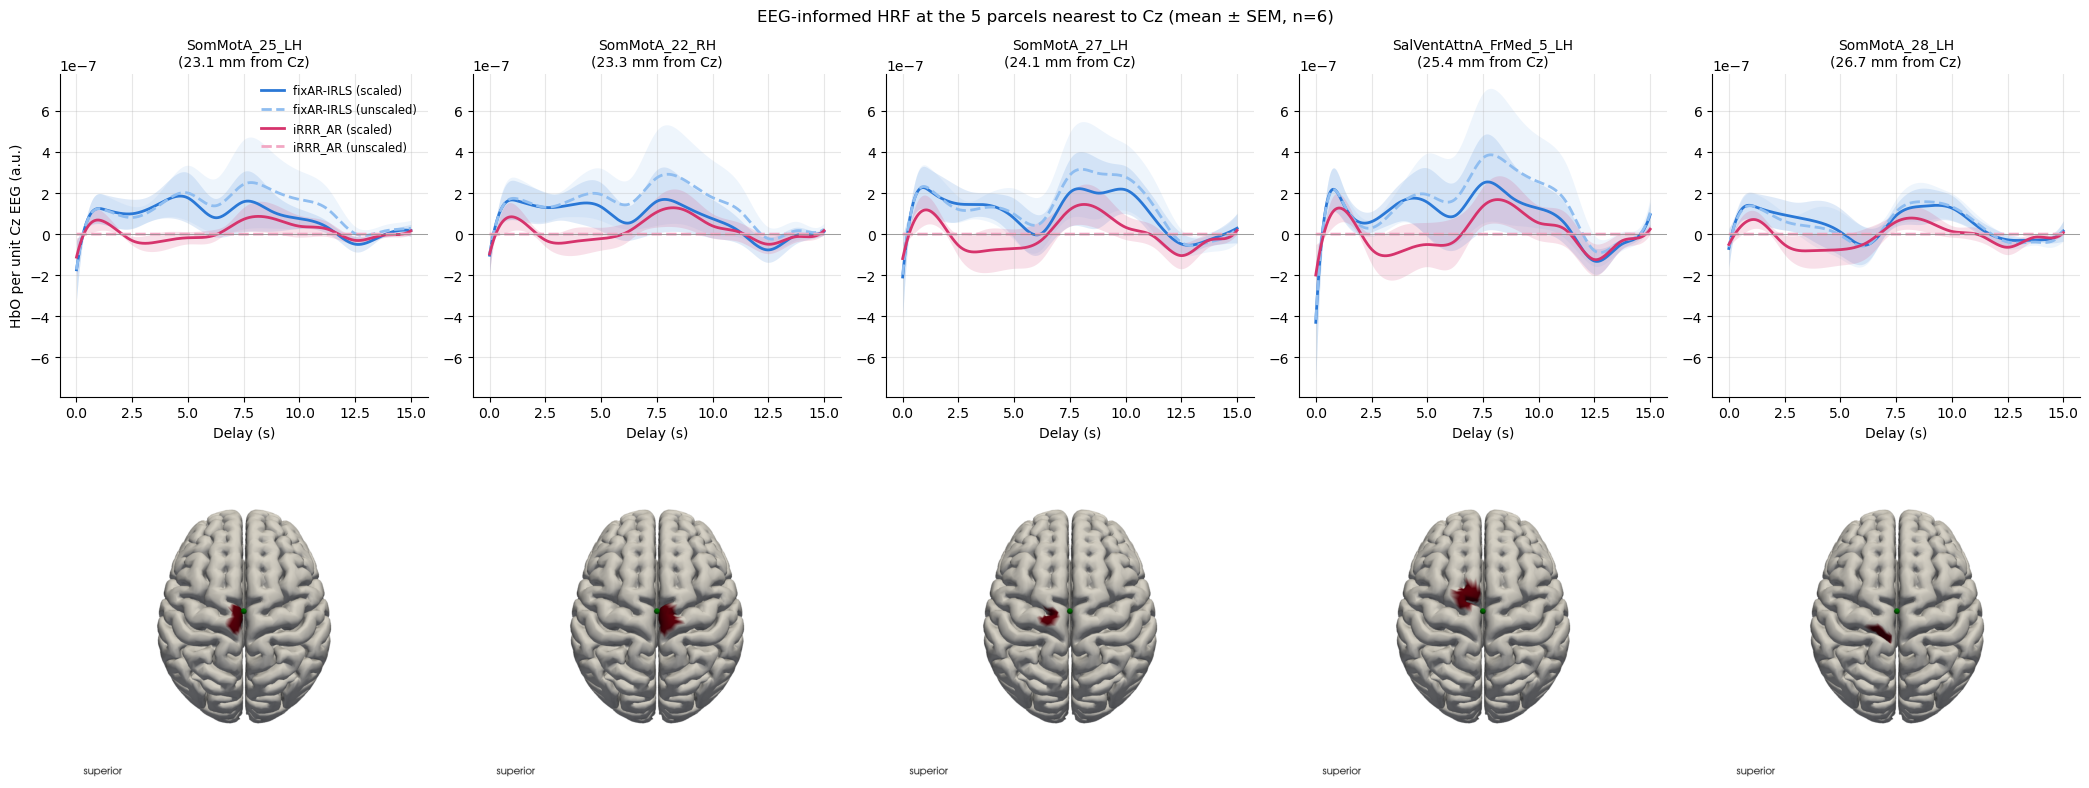

In [6]:
cz_pos = head.landmarks.sel(label='Cz').pint.dequantify().values
vertex_pos = head.brain.vertices.pint.dequantify().values
is_modeled = np.isin(vertex_parcel, parcels)
cz_dist = np.linalg.norm(vertex_pos[is_modeled] - cz_pos, axis=1)
cz_parcels = pd.Series(cz_dist).groupby(vertex_parcel[is_modeled]).min().nsmallest(n_cz_parcels)
print(cz_parcels.round(1).to_string())

parcel_png = {}
for parcel in cz_parcels.index:
    p0, _, _ = image_recon(parcel_to_surf({parcel: 1.0}), head, cmap='Reds', clim=(0, 1), view_type='hbo_brain',
                           view_position='superior', off_screen=True, wdw_size=(800, 800))
    plot_labeled_points(p0, head.landmarks.sel(label=['Cz']))
    parcel_png[parcel] = os.path.join(fig_dir, f'surf_parcel_{parcel}.png')
    p0.screenshot(parcel_png[parcel]); p0.close()

fig, axes = plt.subplots(2, n_cz_parcels, figsize=(4.2 * n_cz_parcels, 8), gridspec_kw={'height_ratios': [1, 1]})
for ax in axes[0, 1:]:
    ax.sharey(axes[0, 0])
for ax, sax, (parcel, dist) in zip(axes[0], axes[1], cz_parcels.items()):
    for lab in labels:
        h = np.stack([hrf[lab][s].sel(parcel=parcel).values for s in subjects])
        m, se = h.mean(0), h.std(0, ddof=1) / np.sqrt(len(h))
        ls = '--' if 'unscaled' in lab else '-'
        ax.plot(delay_t, m, color=colors[lab], lw=2, ls=ls, label=lab)
        ax.fill_between(delay_t, m - se, m + se, color=colors[lab], alpha=0.15, lw=0)
    ax.axhline(0, color='gray', lw=0.5); ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(f'{parcel}\n({dist:.1f} mm from Cz)', fontsize='medium'); ax.set_xlabel('Delay (s)')
    sax.imshow(plt.imread(parcel_png[parcel])); sax.axis('off')
axes[0, 0].set_ylabel(f'{select_chromo} per unit Cz EEG (a.u.)')
axes[0, 0].legend(loc='upper right', fontsize='small', frameon=False)
fig.suptitle(f'EEG-informed HRF at the {n_cz_parcels} parcels nearest to Cz (mean ± SEM, n={len(subjects)})')
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, f'hrf_{n_cz_parcels}_parcels_nearest_Cz.png'), dpi=150)
plt.show()

### Per-subject HRFs at the same parcels
Each panel is one subject at one parcel. Solid lines are scaled fits and dashed lines are unscaled fits.

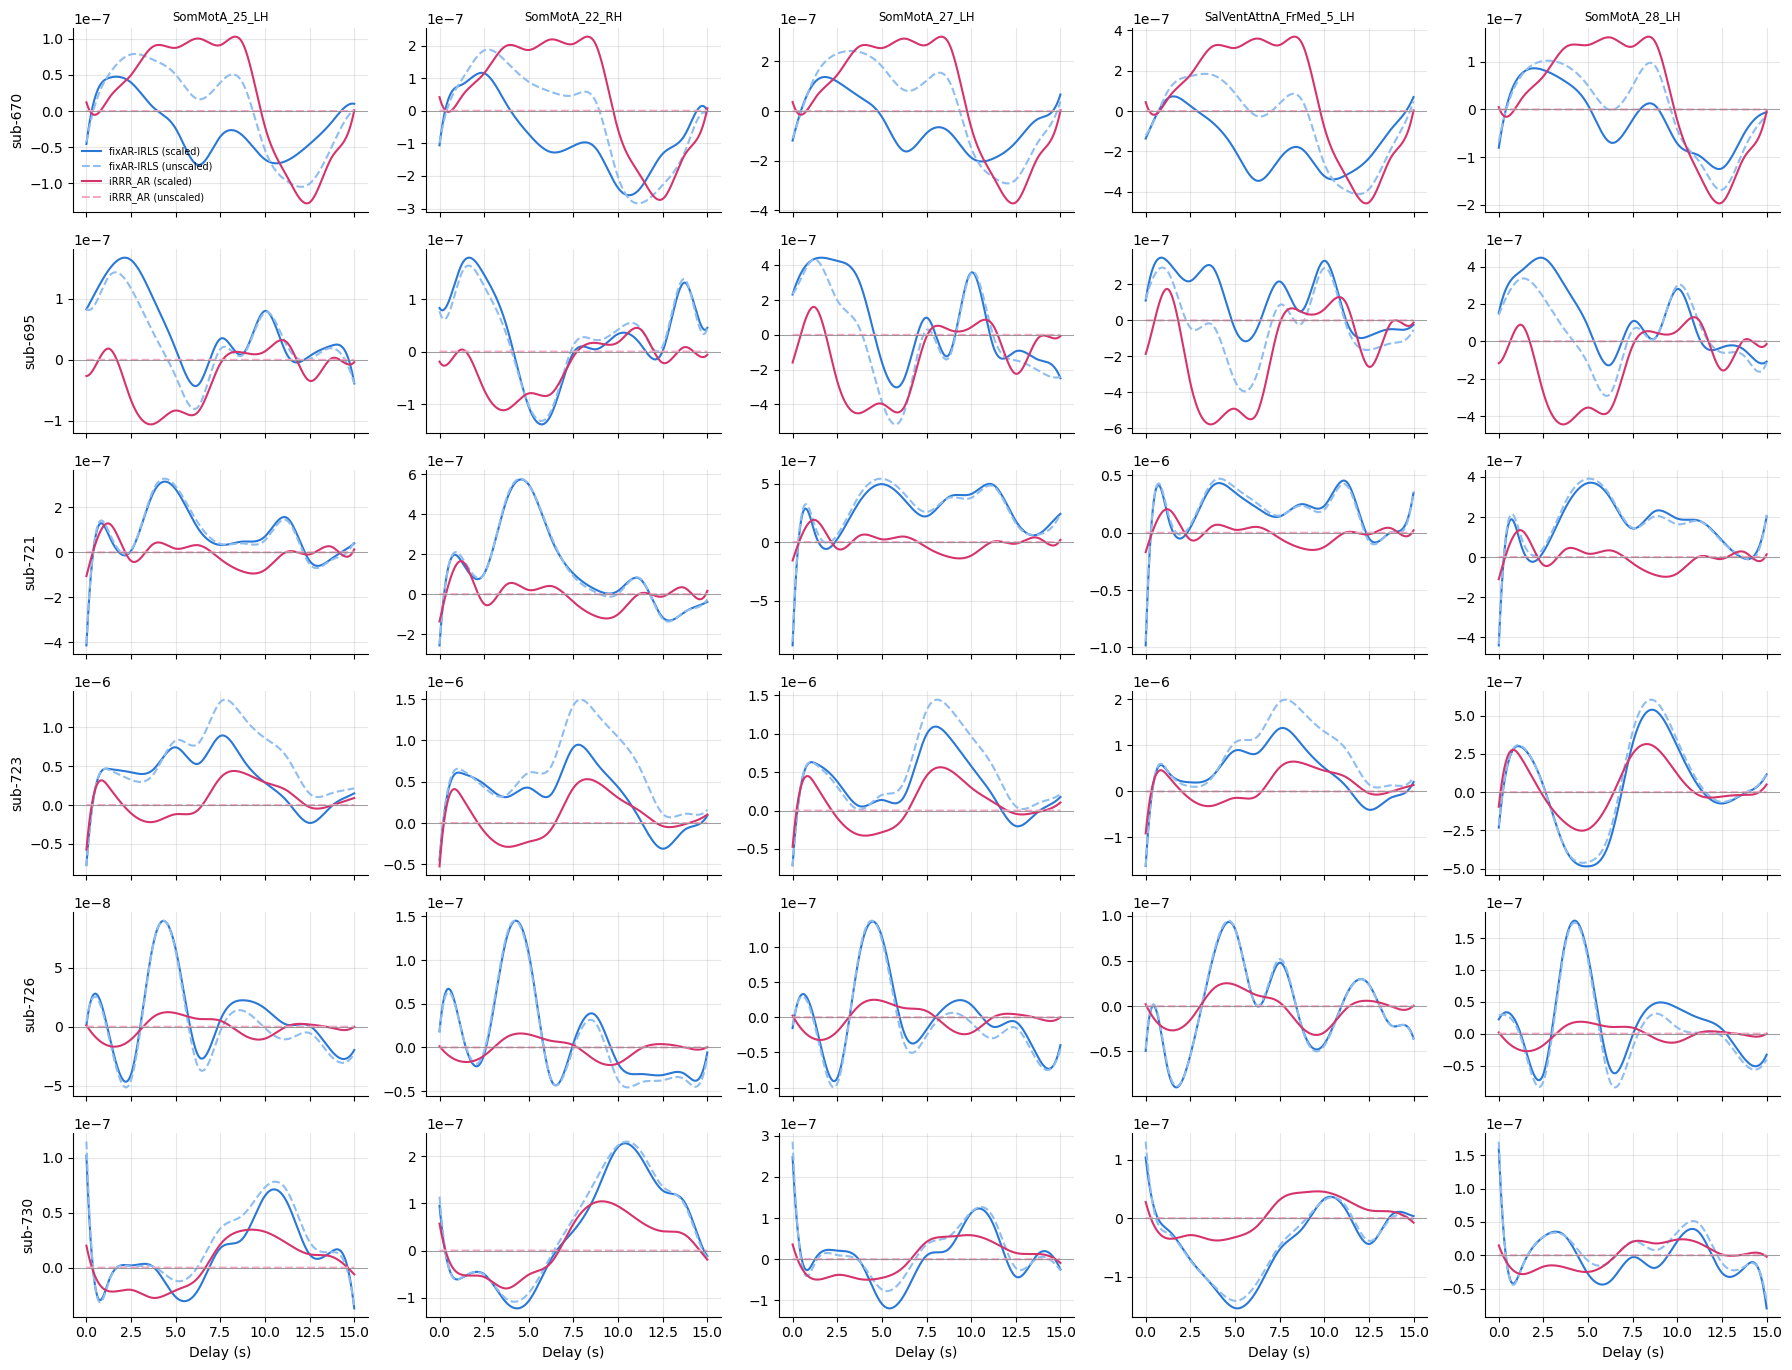

In [7]:
fig, axes = plt.subplots(len(subjects), n_cz_parcels, figsize=(3.6 * n_cz_parcels, 2.3 * len(subjects)),
                         sharex=True, squeeze=False)
for r, subject in enumerate(subjects):
    for c, parcel in enumerate(cz_parcels.index):
        ax = axes[r, c]
        for lab in labels:
            ax.plot(delay_t, hrf[lab][subject].sel(parcel=parcel).values, color=colors[lab],
                    lw=1.5, ls='--' if 'unscaled' in lab else '-', label=lab)
        ax.axhline(0, color='gray', lw=0.5); ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        if r == 0: ax.set_title(parcel, fontsize='small')
        if c == 0: ax.set_ylabel(subject)
for ax in axes[-1]:
    ax.set_xlabel('Delay (s)')
axes[0, 0].legend(fontsize='x-small', frameon=False)
fig.tight_layout()
plt.show()

## 5. iRRR_AR: shared HRF components and per-parcel weights

The iRRR coefficient matrix is low-rank, so all parcels' HRFs are combinations of a few shared shapes. For each subject, we take the SVD of the delay × parcel HRF matrix `betas_eeg = U S Vᵀ`:
- `U[:, k]·S[k]` is the k-th shared HRF shape.
- `Vᵀ[k]` is each parcel's **weight** on that shape, shown on the brain surface. Weight vectors have unit norm, and each map has its own symmetric color scale.

The sign of an SVD component is arbitrary. Each component is flipped so that its HRF has its largest absolute value positive.

Only components up to the fit's rank are non-zero. The unscaled iRRR fits have rank 0 (every coefficient is 0) for every subject, so they have nothing to plot.

iRRR_AR (scaled): rank per subject = {'sub-670': 2, 'sub-695': 2, 'sub-721': 1, 'sub-723': 2, 'sub-726': 2, 'sub-730': 2}


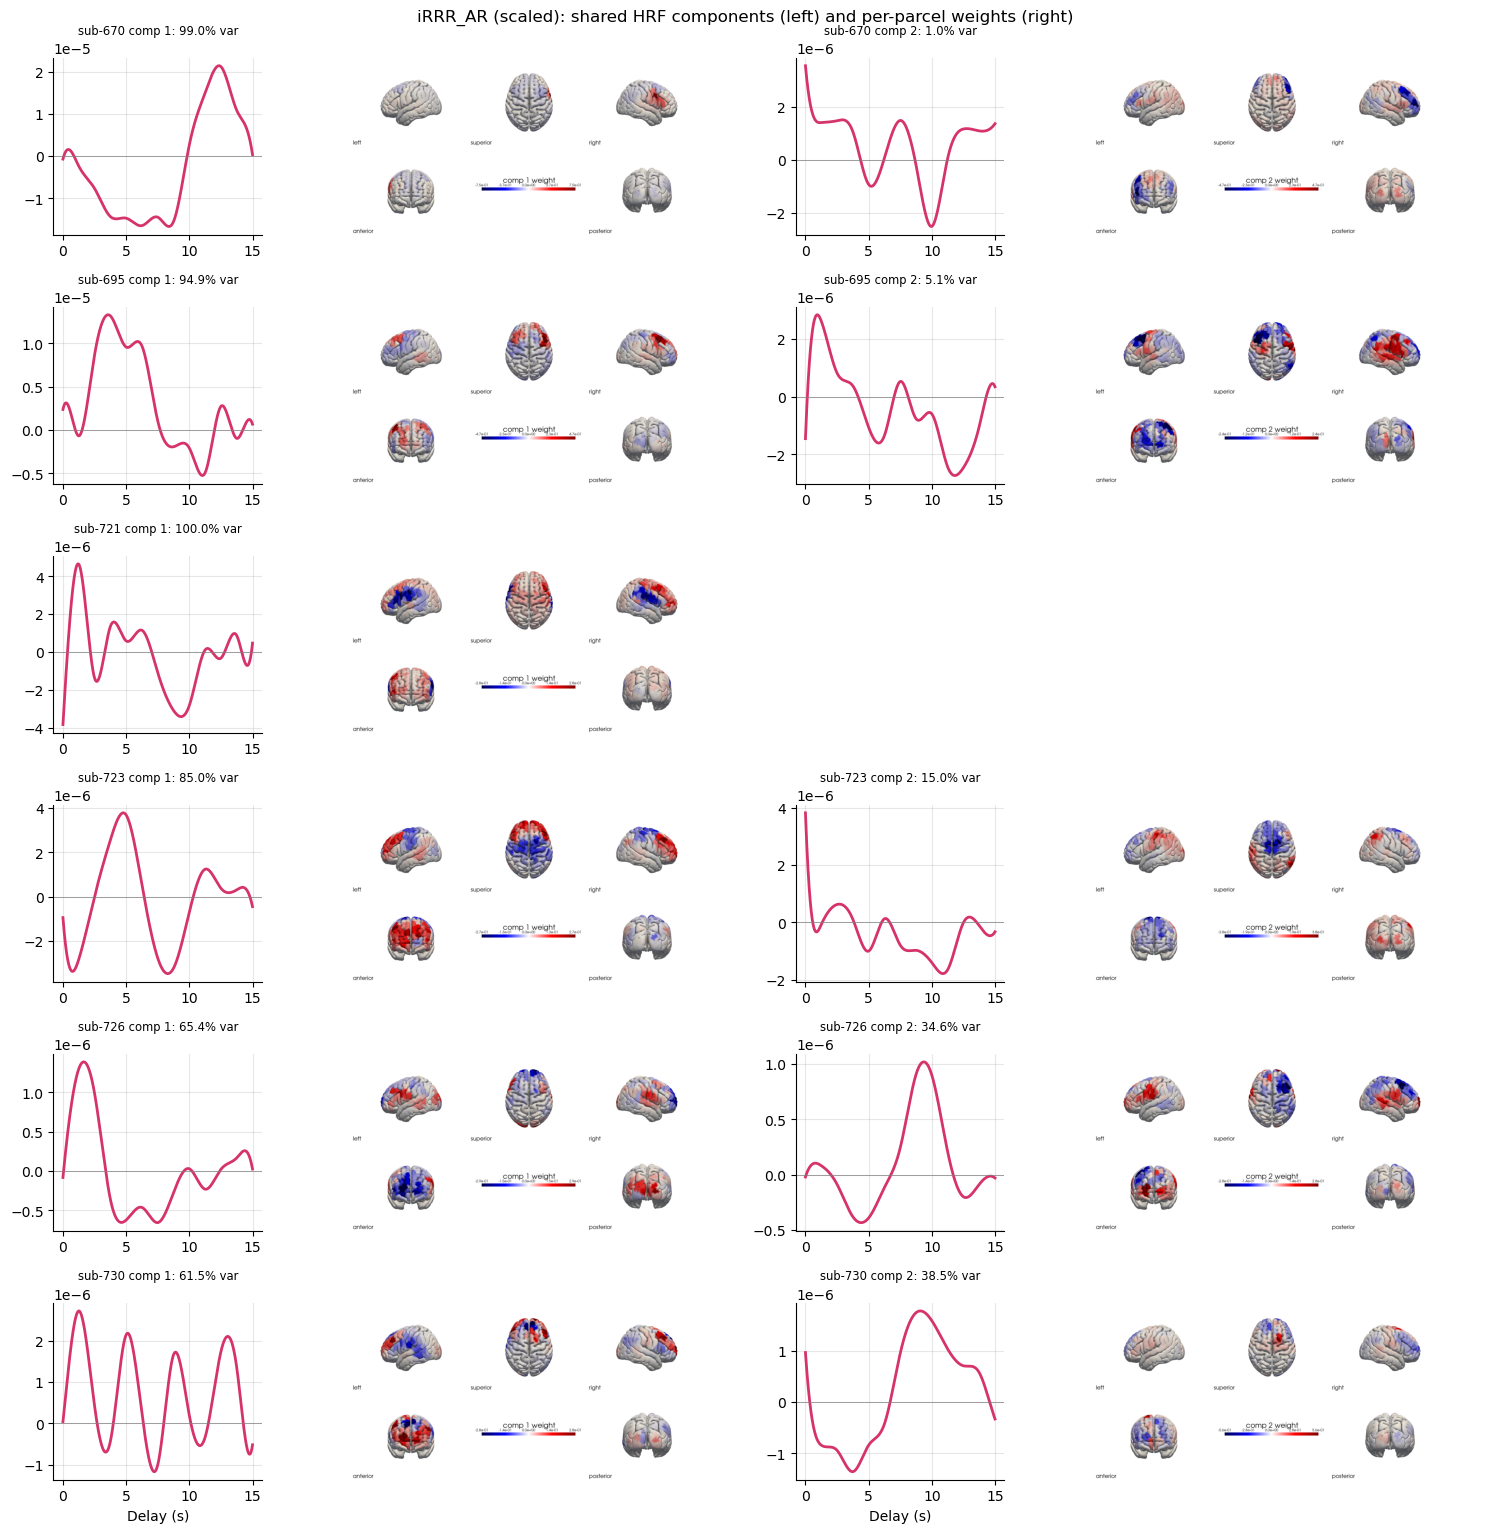

iRRR_AR (unscaled): rank per subject = {'sub-670': 0, 'sub-695': 0, 'sub-721': 0, 'sub-723': 0, 'sub-726': 0, 'sub-730': 0}
  -> iRRR_AR (unscaled): all coefficients are 0 (λ1 = 1 in molar units shrinks everything); nothing to plot.



In [8]:
for lab in [l for l in labels if variants[l][0] == 'iRRR_AR']:
    ranks = {s: int(irrr_stats[lab][s]['rank']) for s in subjects}
    print(f'{lab}: rank per subject = {ranks}')
    max_rank = max(ranks.values())
    if max_rank == 0:
        print(f'  -> {lab}: all coefficients are 0 (λ1 = 1 in molar units shrinks everything); nothing to plot.\n')
        continue

    tag = lab.replace(' ', '_').replace('(', '').replace(')', '')
    fig, axes = plt.subplots(len(subjects), 2 * max_rank, figsize=(7.5 * max_rank, 2.6 * len(subjects)),
                             squeeze=False, gridspec_kw={'width_ratios': [1, 2] * max_rank})
    for r, subject in enumerate(subjects):
        H = hrf[lab][subject].transpose('regressor', 'parcel')
        U, S, Vt = np.linalg.svd(H.values, full_matrices=False)
        for k in range(max_rank):
            ax_h, ax_s = axes[r, 2 * k], axes[r, 2 * k + 1]
            if k >= ranks[subject]:
                ax_h.axis('off'); ax_s.axis('off'); continue
            sgn = np.sign(U[np.argmax(np.abs(U[:, k])), k])
            u, v = U[:, k] * S[k] * sgn, Vt[k] * sgn
            ax_h.plot(delay_t, u, color=colors[lab], lw=2)
            ax_h.axhline(0, color='gray', lw=0.5); ax_h.grid(True, alpha=0.3)
            ax_h.spines[['top', 'right']].set_visible(False)
            ax_h.set_title(f'{subject} comp {k+1}: {S[k]**2 / np.sum(S**2) * 100:.1f}% var', fontsize='small')
            if r == len(subjects) - 1: ax_h.set_xlabel('Delay (s)')
            clim = np.nanmax(np.abs(v))
            png = render_multi_view(dict(zip(H.parcel.values, v)), f'surf_irrr_weight_{tag}_{subject}_comp{k+1}',
                                    'seismic', (-clim, clim), f'comp {k+1} weight')
            ax_s.imshow(plt.imread(png)); ax_s.axis('off')
    fig.suptitle(f'{lab}: shared HRF components (left) and per-parcel weights (right)')
    fig.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'irrr_components_{tag}.png'), dpi=120)
    plt.show()

## Takeaways

**Y scaling matters for both models, for different reasons.**
- **iRRR_AR, unscaled:** every subject has rank 0 and B = 0, so R² = 0. λ₁ = 1 is huge compared with Y in molar units (about 10⁻⁸), so the nuclear-norm penalty removes everything. Scaling is required for λ₁ = 1 to mean anything.
- **fixAR-IRLS, unscaled:** statsmodels `RLM` stops after **2 IRLS iterations**, compared with 25–40 when Y is scaled (checked on sub-670, every 80th parcel). The unscaled fit is therefore an unconverged, nearly-OLS solution. Its betas differ from the scaled fit (HRF r = 0.82–0.997, worst for sub-670 and sub-695).
- Unscaled fixAR-IRLS has the **highest in-sample R²** (0.0059 vs 0.0043). This is expected from a fit closer to OLS, which maximizes unweighted in-sample R². It is not evidence of a better model, because the converged robust fit downweights outlier samples on purpose.

**Scaled models: fixAR-IRLS vs iRRR_AR**
- Mean R² is about the same: 0.0043 ± 0.0009 (fixAR-IRLS) and 0.0042 ± 0.0009 (iRRR_AR). Which model is higher varies by subject: iRRR_AR is higher for sub-670 and sub-695, and fixAR-IRLS is higher for the other four. iRRR_AR does this with a rank-1 or rank-2 HRF space instead of 15 free coefficients per parcel.
- Effect sizes are tiny. R² is below 1% in nearly every parcel, and RMSE is the same to three digits across all variants, so the RMSE maps mostly show where each parcel's noise level is high.
- Near Cz (SomMotA parcels), both models show an early peak at about 1 s and a later positive lobe at about 7–10 s. iRRR_AR is shrunk toward zero and is negative between 2 and 6 s, where fixAR-IRLS stays positive.
- The iRRR component HRFs and weight maps differ a lot between subjects. There is no shared group-level component shape, so these per-subject components should not be averaged.